<a href="https://colab.research.google.com/github/sangramshitole07/AMLAssignment/blob/main/AML_Decision_tree_Iris_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# Import necessary libraries for data manipulation and numerical operations
import pandas as pd
import numpy as np

In [36]:
# Step 2: Import the dataset
# This method allows uploading a file directly to the Colab environment.
from google.colab import files
uploaded=files.upload()

# Read the uploaded CSV file into a pandas DataFrame
dataset=pd.read_csv("Iris.csv")

# Display the loaded dataset
dataset

Saving Iris.csv to Iris (3).csv


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,1
1,2,4.9,3.0,1.4,0.2,1
2,3,4.7,3.2,1.3,0.2,1
3,4,4.6,3.1,1.5,0.2,1
4,5,5.0,3.6,1.4,0.2,1
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,2
146,147,6.3,2.5,5.0,1.9,2
147,148,6.5,3.0,5.2,2.0,2
148,149,6.2,3.4,5.4,2.3,2


In [ ]:
'''
### Alternative ways to load data in Google Colab

**Loading from Google Drive:**

```python
from google.colab import drive
drive.mount('/content/drive')

# Example: Load 'Iris.csv' from the root of your Google Drive
data = pd.read_csv("/content/drive/MyDrive/Iris.csv")

# If your file is inside a folder, e.g., 'AML/Data processing/data'
# data = pd.read_csv("/content/drive/MyDrive/AML/Data processing/data/Data.csv") '''


In [ ]:
### Loading Data in VS Code (Local Environment)

When working in a local environment like VS Code, you can load a CSV file using a relative or absolute path:

```python
import pandas as pd

# If the CSV is in a subfolder named 'data'
data = pd.read_csv("data/Data.csv")

# If the CSV is in the same directory as your script
# data = pd.read_csv("Data.csv")
```

In [39]:
# Check all column names in the dataset
# This helps in understanding the available features for preprocessing.
dataset.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [40]:
# Step 4: Data Inspection - Check for null values, duplicates, and general dataset attributes.
# This step helps to understand data quality and structure.

# Check for missing values in each column
dataset.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [41]:
# Check for duplicate rows in the dataset
dataset.duplicated().sum()

np.int64(0)

In [42]:
# Display descriptive statistics of the numerical columns
# This provides insights into the central tendency, dispersion, and shape of the dataset's distribution.
dataset.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667,1.000000
std,43.445368,0.828066,0.433594,1.764420,0.763161,0.819232
min,1.000000,4.300000,2.000000,1.000000,0.100000,0.000000
25%,38.250000,5.100000,2.800000,1.600000,0.300000,0.000000
50%,75.500000,5.800000,3.000000,4.350000,1.300000,1.000000
75%,112.750000,6.400000,3.300000,5.100000,1.800000,2.000000
max,150.000000,7.900000,4.400000,6.900000,2.500000,2.000000


In [43]:
dataset.info()
# Display a concise summary of the DataFrame, including data types and non-null values.
# This helps determine if encoding (e.g., for categorical or object types) is required.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 7.2 KB


### Understanding `.iloc` for Indexing

`.iloc` stands for **integer-location based indexing**. It's used to select data based on its numerical position.

**Syntax:** `dataset.iloc[rows, columns]`

-   `dataset.iloc[0]`: Selects the row at position 0.
-   `dataset.iloc[:, 0]`: Selects all rows from the column at position 0.
-   `dataset.iloc[:, 1:5]`: Selects all rows and columns from position 1 up to (but not including) 5.

**The `:` (colon) operator**:
-   When used alone (`:`), it means "select all".
-   `iloc[:, 0]` means "take all rows from column 0".
-   `iloc[0, :]` means "take the first row and all its columns".

**`.values`**: This converts the selected pandas DataFrame or Series into a NumPy array, which is often required by machine learning libraries like scikit-learn.

In [44]:
# Step 5: Select the independent features (X) for preprocessing.
# These are the input variables that will be used to predict the target.
# Here, columns at index 1, 2, 3, and 4 (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm) are selected.
X=dataset.iloc[:,[1,2,3,4]].values

# Display the independent features array
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

### Selecting Specific Rows and Columns with `.iloc`

You can select non-contiguous rows and columns using lists of indices:

`dataset.iloc[[0, 2, 4], [1, 3]]`

This selects:
-   Rows at indices 0, 2, and 4
-   Columns at indices 1 and 3

### Why not just use column names?

Using column names with `.loc` (e.g., `X = dataset[["Age", "Salary", "Gender"]]`) is often more readable and robust. It's safer because if the order of your CSV columns changes, the numeric indexes used with `.iloc` might select the wrong data.

However, `.iloc` is very convenient when you're following a known dataset structure or working through machine learning preprocessing exercises where column positions are fixed.

In [45]:
# Step 6: Select the dependent/target feature (Y).
# This is the output variable that the model will learn to predict.
# Here, column at index 5 ('Species') is selected.
Y=dataset.iloc[:,5].values

# Display the target variable array
Y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### `.iloc` vs `.loc`

You'll frequently encounter both `.iloc` and `.loc` for data selection in pandas. Understanding their difference is crucial:

-   **`.iloc` → Position-based Indexing**
    -   Selects data by integer position (index).
    -   Example: `dataset.iloc[:, [1, 2, 3]]` selects columns at positions 1, 2, and 3.

-   **`.loc` → Label-based Indexing**
    -   Selects data by column/row labels (names).
    -   Example: `dataset.loc[:, ["Age", "Salary", "Gender"]]` selects columns named "Age", "Salary", and "Gender".

**Think:**
-   `iloc` → **i**nteger **loc**ation
-   `loc`  → **l**abel **loc**ation

### Modern Python vs. Older Tutorials for `.iloc` with `.values`

In modern versions of scikit-learn and pandas, you often don't explicitly need to convert a DataFrame/Series to a NumPy array using `.values` when passing it to many scikit-learn functions.

For example, you can often do:

`X = dataset.iloc[:, [1, 2, 3]]`

and many scikit-learn functions will work directly with the DataFrame. This can sometimes improve readability and maintain column/row labels.

However, if you're following a machine learning course or tutorial that explicitly uses `.values`, it's perfectly fine to understand and use it, as it ensures compatibility across different library versions or specific function requirements.

In [46]:
## Data Encoding Overview

### Common Patterns for Feature and Target Selection

For machine learning preprocessing, a common pattern to separate independent features (X) and the target variable (y) using `.iloc` is:

`X = dataset.iloc[:, feature_columns].values`
`y = dataset.iloc[:, target_column].values`

**Examples of `iloc` usage:**

-   **Columns 1, 2, 3:**
    `X = dataset.iloc[:, [1, 2, 3]].values`

-   **Columns 1 through 4 (exclusive of 5):**
    `X = dataset.iloc[:, 1:5].values`

-   **Everything except the last column:**
    `X = dataset.iloc[:, :-1].values`

-   **Only the last column:**
    `y = dataset.iloc[:, -1].values`

-   **Only the first column:**
    `X = dataset.iloc[:, 0].values`

The most important thing is to understand the structure: `dataset.iloc[ROWS, COLUMNS]`. Once you grasp this, `.iloc` becomes much easier to use effectively.

In [47]:
# Step 7: Consider Label Encoding (not needed for this dataset)
# Label encoding is used to convert categorical text labels into numerical format.
# In this specific Iris dataset, the 'Species' column (our target Y) is already numerical (0, 1, 2),
# and the independent features (X) are all numerical, so no label encoding is required for X or Y.

### When to use Label Encoding vs. One-Hot Encoding

**Label Encoding:**
-   Suitable for **ordinal categories** (categories with a meaningful order, e.g., Low < Medium < High).
-   Also acceptable for **binary categories** (only two unique values, e.g., Male/Female).

**One-Hot Encoding:**
-   Essential for **nominal categories** (categories with NO inherent meaningful order, e.g., colors, countries).

**Example Scenario:**
Consider a dataset with features like `Age` (numerical), `Salary` (numerical), `Gender` (categorical: Male/Female), and `Country` (categorical: India/USA/France).

Machine learning algorithms generally require numerical input. So, we need to convert:
-   `Male` → ?
-   `Female` → ?
-   `India` → ?
-   `USA` → ?
-   `France` → ?

This is where `LabelEncoder` and `OneHotEncoder` from scikit-learn come into play.

### How Label Encoding Works

Label encoding assigns a unique integer to each category based on alphabetical order or order of appearance.

**Example:**
-   `Male`   → 1
-   `Female` → 0

Or for ordinal data:
-   `Low`    → 0
-   `Medium` → 1
-   `High`   → 2

**Using `sklearn.preprocessing.LabelEncoder`:**

```python
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset["Gender"] = le.fit_transform(dataset["Gender"])
```

After transformation, a `Gender` column might look like:

| Gender   | Encoded |
| :------- | :------ |
| Female   | 0       |
| Male     | 1       |

### The Critical Problem with Blind Label Encoding

Suppose you have a categorical feature like `Country` with values:

-   `India`
-   `France`
-   `Germany`

If you apply label encoding, it might arbitrarily assign integers, for example:

-   `France`  → 0
-   `Germany` → 1
-   `India`   → 2

The problem is that a machine learning model might misinterpret this numerical assignment as an ordinal relationship. For instance, it might infer:

-   `India` > `Germany` > `France`
-   Or, `India` is "twice" `France` in some magnitude.

This interpretation is nonsensical because there's no inherent numerical order or magnitude between countries. Introducing such an artificial relationship can negatively impact model performance, especially for algorithms sensitive to numerical scales. This is why using `LabelEncoder` indiscriminately for all categorical columns is generally a bad idea.

### When is Label Encoding Appropriate?

**Case 1: Binary Categories**

If a categorical feature has only two unique values, label encoding is usually acceptable. The model learns to differentiate between two states, and the numerical order (0 and 1) typically doesn't create problematic ordinal assumptions.

**Example:** `Purchased`
-   `No`  → 0
-   `Yes` → 1

**Example:** `Gender`
-   `Female` → 0
-   `Male`   → 1

**Case 2: Ordinal Data**

This is the most suitable scenario for label encoding. When there's a genuine, meaningful order among categories, assigning increasing integers preserves this intrinsic relationship.

**Example:** `Education Level`
-   `High School` → 0
-   `Bachelor`    → 1
-   `Master`      → 2
-   `PhD`         → 3

Here, the order `High School < Bachelor < Master < PhD` is naturally preserved by the numerical mapping.

**Example:** `Satisfaction Rating`
-   `Bad`       → 0
-   `Average`   → 1
-   `Good`      → 2
-   `Excellent` → 3

### When to AVOID Label Encoding (Use One-Hot Encoding Instead)

Avoid label encoding for **nominal data** where there is no natural or meaningful order.

**Example:** `Color`
-   `Red`
-   `Blue`
-   `Green`

If you encode this as `Red → 0`, `Blue → 1`, `Green → 2`, you are implying an order (`Red < Blue < Green`) that does not exist. This can lead to incorrect model interpretations. For such situations, **One-Hot Encoding** is the correct approach.

### How One-Hot Encoding Works

One-Hot Encoding creates a new binary column for each category in a feature. Each new column indicates the presence (1) or absence (0) of that specific category.

**Example:** Consider a `Color` feature with values:

-   `Red`
-   `Blue`
-   `Green`

One-Hot Encoding transforms this into separate columns:

| Red | Blue | Green |
| :-- | :--- | :---- |
| 1   | 0    | 0     | (for 'Red')
| 0   | 1    | 0     | (for 'Blue')
| 0   | 0    | 1     | (for 'Green')

Each row will have a `1` in the column corresponding to its category and `0` in all other new columns. This method avoids imposing any artificial ordinal relationships between categories.

In [48]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets.
# X: Independent features, Y: Dependent (target) feature
# test_size=0.2 means 20% of the data will be used for testing, and 80% for training.
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2)

In [49]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler.
# StandardScaler standardizes features by removing the mean and scaling to unit variance.
sc=StandardScaler()

# Fit the scaler on the training data and transform it.
# The scaler learns the mean and standard deviation from X_train.
X_train=sc.fit_transform(X_train)

# Transform the test data using the *same* scaler fitted on X_train.
# It's crucial to use the same scaling parameters to prevent data leakage.
X_test=sc.transform(X_test)

In [50]:
# Display the scaled test set.
# The values are now standardized (mean=0, variance=1).
X_test

array([[ 0.50635048, -0.32819243,  1.02583271,  0.78026885],
       [ 0.97375092,  0.15503569,  1.02583271,  1.57713916],
       [-0.89585085,  0.6382638 , -1.21234774, -0.9462835 ],
       [-1.12955107, -0.08657837, -1.38451547, -1.34471865],
       [ 0.15580015, -0.81142054,  0.7388865 ,  0.51464541],
       [-0.89585085,  1.12149192, -1.38451547, -1.34471865],
       [-0.89585085, -1.29464866, -0.46628759, -0.14941318],
       [-1.24640118,  0.15503569, -1.26973699, -1.34471865],
       [ 0.38950037, -2.01949083,  0.39455104,  0.38183369],
       [-0.4284504 , -1.53626272, -0.0645629 , -0.2822249 ],
       [ 0.50635048,  0.87987786,  1.02583271,  1.57713916],
       [-1.24640118, -0.08657837, -1.38451547, -1.21190694],
       [-0.54530051,  0.87987786, -1.21234774, -1.34471865],
       [ 0.97375092, -0.08657837,  0.68149725,  0.64745713],
       [ 0.15580015, -0.32819243,  0.39455104,  0.38183369],
       [-1.24640118, -0.08657837, -1.38451547, -1.47753037],
       [ 0.15580015,  0.

In [51]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier.
# 'criterion="entropy"' specifies the information gain as the splitting criterion.
# 'random_state=0' ensures reproducibility of the results.
classifier=DecisionTreeClassifier(criterion="entropy",random_state=0)

# Train the classifier using the scaled training data.
# The model learns patterns from X_train to predict Y_train.
classifier.fit(X_train,Y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [52]:
# Make predictions on the scaled test set using the trained classifier.
y_pred=classifier.predict(X_test)

# Display the predicted values for the test set.
y_pred

array([2, 2, 1, 1, 2, 1, 0, 1, 0, 0, 2, 1, 1, 2, 0, 1, 0, 1, 0, 0, 2, 0,
       2, 1, 1, 1, 2, 1, 2, 2])

In [53]:
# Display the actual target values for the test set.
Y_test

array([2, 2, 1, 1, 0, 1, 0, 1, 0, 0, 2, 1, 1, 0, 0, 1, 0, 1, 0, 0, 2, 0,
       2, 1, 1, 1, 2, 1, 2, 2])

In [54]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix.
# This matrix summarizes the performance of the classification model on the test data.
cm =confusion_matrix(Y_test,y_pred)

print('Confusion Matrix')
print(cm)

Confusion Matrix
[[ 8  0  2]
 [ 0 12  0]
 [ 0  0  8]]


In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate overall accuracy of the model.
accuracy = accuracy_score(Y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

# For multi-class classification, calculate precision, recall, and F1-score per class.
# 'average='weighted'' accounts for class imbalance by computing metrics for each label,
# and finding their average weighted by support (the number of true instances for each label).
precision = precision_score(Y_test, y_pred, average='weighted')
recall = recall_score(Y_test, y_pred, average='weighted')
f1 = f1_score(Y_test, y_pred, average='weighted')

print(f'Precision (weighted): {precision:.4f}')
print(f'Recall (weighted): {recall:.4f}')
print(f'F1-Score (weighted): {f1:.4f}')

Accuracy: 0.9333
Precision (weighted): 0.9467
Recall (weighted): 0.9333
F1-Score (weighted): 0.9333


In [56]:
num_classes = cm.shape[0]
labels = np.unique(Y_test)

print('\nMetrics per class (One-vs-Rest):')
# Iterate through each class to calculate its individual True Positives, False Positives, etc.
# This uses a 'one-vs-rest' approach, treating one class as positive and all others as negative.
for i, class_label in enumerate(labels):
    # True Positives (TP): Correctly predicted instances of the current class_label
    TP = cm[i, i]

    # False Positives (FP): Instances incorrectly predicted as the current class_label (actually another class)
    FP = cm[:, i].sum() - TP

    # False Negatives (FN): Instances of the current class_label incorrectly predicted as another class
    FN = cm[i, :].sum() - TP

    # True Negatives (TN): Instances correctly predicted as *not* the current class_label
    TN = cm.sum() - (TP + FP + FN)

    print(f'\nClass: {class_label}')
    print(f'  TP: {TP}')
    print(f'  FP: {FP}')
    print(f'  FN: {FN}')
    print(f'  TN: {TN}')


Metrics per class (One-vs-Rest):

Class: 0
  TP: 8
  FP: 0
  FN: 2
  TN: 20

Class: 1
  TP: 12
  FP: 0
  FN: 0
  TN: 18

Class: 2
  TP: 8
  FP: 2
  FN: 0
  TN: 20


### Using the Classifier to Predict New Data

Now that the model is trained, let's see how it predicts the species of a new Iris flower. We need to remember to scale the new data point using the same `StandardScaler` (`sc`) that was used for the training data.

In [57]:
# Example new data point for an Iris flower with measurements:
# (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm)
new_iris_sample = np.array([[5.8, 2.7, 5.1, 1.9]])

# Scale the new data point using the *same* StandardScaler (`sc`) fitted on the training data.
# This is crucial for consistent preprocessing.
scaled_new_iris_sample = sc.transform(new_iris_sample)

# Make a prediction using the trained classifier on the scaled new data point.
prediction = classifier.predict(scaled_new_iris_sample)

print(f'The predicted species class for the new Iris sample is: {prediction[0]}')

# Map the numerical prediction back to the original species names for better interpretation.
# Based on common Iris datasets, the encoding is typically:
# 0: Iris-setosa
# 1: Iris-versicolor
# 2: Iris-virginica

if prediction[0] == 0:
    print('This corresponds to Iris-setosa')
elif prediction[0] == 1:
    print('This corresponds to Iris-versicolor')
elif prediction[0] == 2:
    print('This corresponds to Iris-virginica')
else:
    print('Unknown species class.')

The predicted species class for the new Iris sample is: 2
This corresponds to Iris-virginica


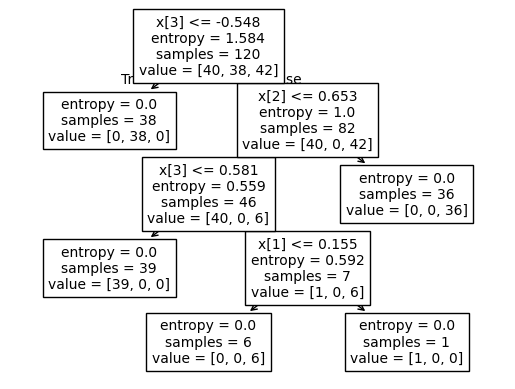

In [61]:
import matplotlib.pyplot as plt

from sklearn import tree
tree.plot_tree(classifier)
plt.show()